# Read EnergyPlus results into a results table

Inputs: the `.sql` files written by `BEM4AI_7_Simulation.ipynb`, one per simulated `sample_id`.

Steps:

1. Flatten any `eplusout.sql` still nested inside a run folder into `SQL_DIR`.
2. Parse every SQL file for EUI, end uses and design peak loads.
3. Assemble one row per model, keyed by `sample_id`.
4. Save the table and review the distribution of every column.

Outputs: `data/interim/sim_results_df.csv`, plus `data/interim/bad_sql_files.csv` if any SQL file failed to parse.

In [1]:
import warnings
import math
import shutil
import sqlite3
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator
from tqdm import TqdmWarning, tqdm

warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)

from ladybug.sql import ZoneSize
from helpers.paths import PROJECT_ROOT, INTERIM_DIR, display_path


# Energy units distinguish annual energy values from water volumes and peak-demand values in the same EnergyPlus tables.
ENERGY_UNITS = ("GJ", "MJ", "kWh")


def _tabular(rows, keep_units=None):
    """Group EnergyPlus tabular rows by row name, converting energy values to kWh.

    Mirrors ladybug's ``SQLiteResult.tabular_data_by_name(j_to_kwh=True)``. When
    ``keep_units`` is given, only values carrying those units are kept.
    """
    table = OrderedDict()
    for row_name, value, units in rows:
        if keep_units is not None and units.strip() not in keep_units:
            continue
        try:
            val = float(value)
            if "GJ" in units:
                val = val / 0.0036
            elif "MJ" in units:
                val = val / 3.6
        except ValueError:  # not a number
            val = value
        table.setdefault(row_name, []).append(val)
    return table


def read_sql_results(sql_path, use_final=True):
    """Read EUI, end uses and design peak loads from one EnergyPlus SQL file.

    Opens the file once. Energies are returned in kWh and kWh/m2, areas in m2 and
    loads in W. ``use_final=True`` reads the design loads EnergyPlus sized the
    equipment with; ``False`` reads the unfactored calculated loads.
    """
    conn = sqlite3.connect(str(sql_path))
    try:
        cur = conn.cursor()
        tabular = "SELECT RowName, Value, Units FROM TabularDataWithStrings WHERE TableName=?"
        cur.execute(tabular, ("Building Area",))
        area_rows = cur.fetchall()
        # The same table name appears in annual-energy and peak-demand reports; select the annual report.
        cur.execute(
            "SELECT RowName, Value, Units FROM TabularDataWithStrings "
            "WHERE TableName=? AND ReportName=?",
            ("End Uses By Subcategory", "AnnualBuildingUtilityPerformanceSummary"),
        )
        end_use_rows = cur.fetchall()
        cur.execute("SELECT * FROM ZoneSizes WHERE LoadType=?", ("Cooling",))
        cooling_rows = cur.fetchall()
        cur.execute("SELECT * FROM ZoneSizes WHERE LoadType=?", ("Heating",))
        heating_rows = cur.fetchall()
    finally:
        conn.close()

    # Floor areas
    # Look up areas by row name so an EnergyPlus ordering change cannot swap total and conditioned area.
    area_table = _tabular(area_rows)
    try:
        total_floor_area = area_table["Total Building Area"][0]
        conditioned_floor_area = area_table["Net Conditioned Building Area"][0]
    except (KeyError, IndexError):
        raise ValueError(
            'Could not read "Total Building Area" and "Net Conditioned Building Area" '
            f'from the "Building Area" table. Rows present: {list(area_table)}'
        ) from None

    # Energy use by end use
    # Select columns by unit so new fuel columns are included while water-volume columns remain excluded.
    total_energy = 0.0
    end_uses = OrderedDict()
    for category, vals in _tabular(end_use_rows, keep_units=ENERGY_UNITS).items():
        total_use = sum(vals)
        if total_use != 0:
            total_energy += total_use
            # Use a named subcategory as the output label; retain the end-use label for generic subcategories.
            cat, _, sub_cat = category.partition(":")
            eu_cat = cat if sub_cat in ("General", "Other", "") else sub_cat
            end_uses[eu_cat] = end_uses.get(eu_cat, 0) + total_use

    if total_floor_area != 0:
        eui = round(total_energy / total_floor_area, 3)
        end_use_out = OrderedDict(
            (k, round(v / total_floor_area, 3)) for k, v in end_uses.items())
    else:
        eui = 0.0
        end_use_out = OrderedDict((k, 0.0) for k in end_uses)

    # Design peak loads
    attr = "final_design_load" if use_final else "calculated_design_load"
    cool = [ZoneSize(r) for r in cooling_rows]
    heat = [ZoneSize(r) for r in heating_rows]
    peak_cooling_w = sum(getattr(z, attr) for z in cool)
    peak_heating_w = sum(getattr(z, attr) for z in heat)

    return {
        "eui": eui,
        "total_floor_area": total_floor_area,
        "conditioned_floor_area": conditioned_floor_area,
        "total_energy": round(total_energy, 3),
        "end_uses": end_use_out,
        "peak_cooling_w": float(peak_cooling_w),
        "peak_heating_w": float(peak_heating_w),
        "peak_cooling_kw": float(peak_cooling_w) / 1000.0,
        "peak_heating_kw": float(peak_heating_w) / 1000.0,
        "max_zone_cooling_w": float(max((getattr(z, attr) for z in cool), default=0.0)),
        "max_zone_heating_w": float(max((getattr(z, attr) for z in heat), default=0.0)),
        "n_cooling_zones": len(cool),
        "n_heating_zones": len(heat),
    }


# Notebook 6 writes flattened `<sample_id>.sql` files to the simulation-output directory.
SIM_OUTPUT_DIR = PROJECT_ROOT / "output" / "simulations"
SQL_DIR = SIM_OUTPUT_DIR

if not SIM_OUTPUT_DIR.is_dir():
    raise FileNotFoundError(
        f"Simulation folder not found: {SIM_OUTPUT_DIR}\n"
        "Run BEM4AI_7_Simulation.ipynb first."
    )

print(f"Simulation results: {display_path(SIM_OUTPUT_DIR)}")
print(f"SQL files:          {display_path(SQL_DIR)}")

Simulation results: output/simulations
SQL files:          output/simulations


### Flatten EnergyPlus SQL outputs

Notebook 6 moves each successful run's `eplusout.sql` to `<sample_id>.sql` as it goes, so this step usually finds nothing. It exists for older runs and for failed runs whose folders were kept.

Steps:
1. Find any `eplusout.sql` still nested under `SIM_OUTPUT_DIR`.
2. Move each one to `SQL_DIR` as `{sample_id}.sql`, taking the name from the run folder (a `run/` subfolder is skipped). Files whose target already exists are left in place rather than overwritten.
3. Report how many were moved, skipped, and how many `.sql` files are now in `SQL_DIR`.

In [2]:
SQL_DIR.mkdir(parents=True, exist_ok=True)


def sql_name_for(sql_path: Path) -> str:
    """`<sample_id>.sql` for a nested eplusout.sql, whether or not it sits in `run/`."""
    folder = sql_path.parent
    if folder.name == "run":  # EnergyPlus writes into a `run/` subfolder in some layouts
        folder = folder.parent
    return f"{folder.name}.sql"


nested_sql = list(SIM_OUTPUT_DIR.rglob("eplusout.sql"))
print(f"Found {len(nested_sql)} nested eplusout.sql file(s) to flatten.")

moved, skipped = 0, 0
for src in nested_sql:
    dst = SQL_DIR / sql_name_for(src)
    if dst.exists():
        skipped += 1
        continue
    shutil.move(str(src), str(dst))
    moved += 1

if skipped:
    print(f"Left {skipped} file(s) in place: a .sql of the same name already exists.")
print(f"Moved {moved} file(s). Total .sql files in {SQL_DIR.name}: {len(list(SQL_DIR.glob('*.sql')))}")

Found 0 nested eplusout.sql file(s) to flatten.
Moved 0 file(s). Total .sql files in simulations: 12


### Read the SQL files and extract EUI and peak-load metrics

Inputs: `SQL_DIR` containing `{sample_id}.sql`, the `read_sql_results` parser defined above, and `INTERIM_DIR`.

Steps:
1. Index every `*.sql` in `SQL_DIR`, using the filename stem as `sample_id`.
2. Parse each file for EUI, end uses and design peak loads; collect failures instead of stopping.
3. Assemble a table keyed by `sample_id`, with totals, per-end-use values and peak heating/cooling loads.
4. Fill missing end-use columns with `0.0`: an end use absent from the SQL means that use consumed no energy.
5. Write `bad_sql_files.csv` when any file failed to parse.

Outputs: `sim_results_df` indexed by `sample_id`, and `bad_sql_df` listing unparseable files.

> The index is the **`sample_id`** (`Athens_0001`), the id notebook 2 assigns and notebook 6 simulates under — not the OSM `building_id`. Join downstream tables on `sample_id`.

In [3]:
# Use the filename stem as the `sample_id` assigned in Notebook 2 and simulated in Notebook 6.
sql_files_by_sample_id = {
    p.stem: p
    for p in SQL_DIR.glob("*.sql")
    if not p.name.startswith("._")  # macOS resource forks
}
print(f"Indexed {len(sql_files_by_sample_id)} SQL file(s) in {display_path(SQL_DIR)}")

rows, bad_sql = [], []

for sample_id, sql_path in tqdm(
    sql_files_by_sample_id.items(),
    total=len(sql_files_by_sample_id),
    desc="Parsing EnergyPlus SQL"
):
    try:
        res = read_sql_results(sql_path)
    except Exception as e:
        print(f"[BAD SQL] {sample_id}: {e}")
        bad_sql.append({
            "sample_id": sample_id,
            "path": str(sql_path),
            "error": repr(e),
        })
        continue

    eui_val = res["eui"]
    total_energy = res["total_energy"]
    total_floor_area = res["total_floor_area"]
    conditioned_floor_area = res["conditioned_floor_area"]

    end_uses = res["end_uses"] or {}
    heating_eui = end_uses.get("Heating", 0.0)
    cooling_eui = end_uses.get("Cooling", 0.0)

    ref_floor_area = conditioned_floor_area or total_floor_area or 0.0
    # Recover annual energy with total floor area; use conditioned area when available for peak intensities.
    annual_heating = heating_eui * total_floor_area
    annual_cooling = cooling_eui * total_floor_area

    row = {
        "sample_id": sample_id,
        "eui_kwh_per_m2": eui_val,
        "total_energy_kwh": total_energy,
        "total_floor_area_m2": total_floor_area,
        "conditioned_floor_area_m2": conditioned_floor_area,
        "heating_eui_kwh_per_m2": heating_eui,
        "cooling_eui_kwh_per_m2": cooling_eui,
        "ref_floor_area_m2": ref_floor_area,
        "annual_heating_kwh": annual_heating,
        "annual_cooling_kwh": annual_cooling,
        "annual_heating_plus_cooling_kwh": annual_heating + annual_cooling,

        # Design peak loads
        "peak_cooling_w": res["peak_cooling_w"],
        "peak_heating_w": res["peak_heating_w"],
        "peak_cooling_kw": res["peak_cooling_kw"],
        "peak_heating_kw": res["peak_heating_kw"],
        "max_zone_cooling_w": res["max_zone_cooling_w"],
        "max_zone_heating_w": res["max_zone_heating_w"],
        "n_cooling_zones": res["n_cooling_zones"],
        "n_heating_zones": res["n_heating_zones"],

        # Peak intensity per square metre of reference floor area
        "peak_cooling_w_per_m2": (res["peak_cooling_w"] / ref_floor_area) if ref_floor_area else None,
        "peak_heating_w_per_m2": (res["peak_heating_w"] / ref_floor_area) if ref_floor_area else None,
    }

    for end_use_name, value in end_uses.items():
        row[f"end_use_{end_use_name.replace(' ', '_')}"] = value

    rows.append(row)

sim_results_df = pd.DataFrame(rows).set_index("sample_id").sort_index()

# A missing end-use column means that use consumed no energy, so fill it with `0.0`.
end_use_cols = [c for c in sim_results_df.columns if c.startswith("end_use_")]
filled = int(sim_results_df[end_use_cols].isna().sum().sum())
sim_results_df[end_use_cols] = sim_results_df[end_use_cols].fillna(0.0)

print(f"Successfully extracted results for {len(sim_results_df)} models.")
if filled:
    print(f"Filled {filled} missing end-use value(s) with 0.0 across {len(end_use_cols)} end-use columns.")

bad_sql_df = pd.DataFrame(bad_sql)
if not bad_sql_df.empty:
    bad_sql_csv = INTERIM_DIR / "bad_sql_files.csv"
    bad_sql_df.to_csv(bad_sql_csv, index=False)
    print(f"{len(bad_sql_df)} SQL file(s) could not be parsed; wrote {display_path(bad_sql_csv)}")
else:
    print("All SQL files parsed successfully.")

Indexed 12 SQL file(s) in output/simulations


Parsing EnergyPlus SQL: 100%|██████████| 12/12 [00:00<00:00, 183.51it/s]

Successfully extracted results for 12 models.
Filled 2 missing end-use value(s) with 0.0 across 5 end-use columns.
All SQL files parsed successfully.


### Save the results table

Writes `sim_results_df` to `data/interim/sim_results_df.csv`, indexed by `sample_id`. This is the
final table of the pipeline: one row per simulated model, joinable to the rest of the dataset on
`sample_id`.

In [4]:
sim_csv_path = INTERIM_DIR / "sim_results_df.csv"
sim_results_df.to_csv(sim_csv_path, index=True)
print(f"Saved: {display_path(sim_csv_path)} ({len(sim_results_df)} rows)")

Saved: data/interim/sim_results_df.csv (12 rows)


### Review the distribution of every saved column

Reads the CSV back from disk and draws one histogram per numeric column, so what is reviewed is
what was written rather than the in-memory frame. This is a sanity check: look for columns that
are entirely zero or constant, distributions squeezed against zero, and isolated extreme values
worth tracing back to the model that produced them.

Outputs: a grid of histograms, plus a printed count of rows, columns, and any column that is
constant or empty.

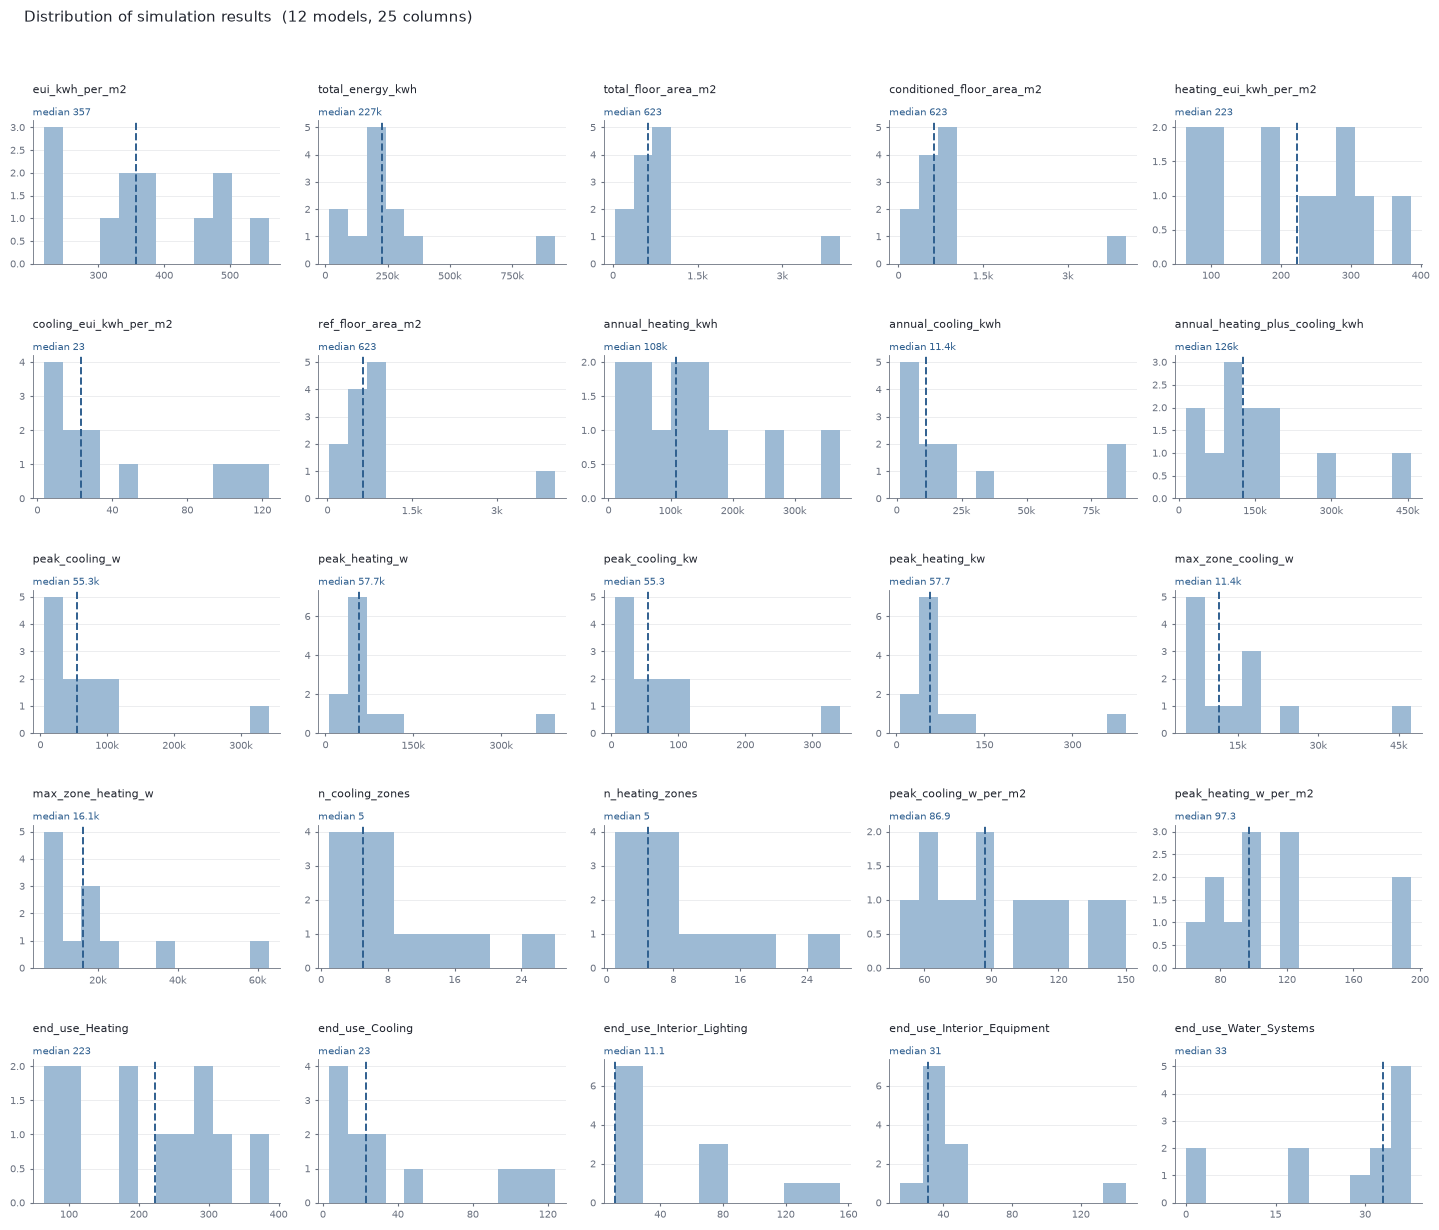

12 models, 25 numeric column(s) in sim_results_df.csv
No constant or empty columns.


In [5]:
# Read the saved results table.
plot_df = pd.read_csv(sim_csv_path, index_col="sample_id")
numeric_cols = [c for c in plot_df.columns if pd.api.types.is_numeric_dtype(plot_df[c])]

INK, MUTED, FILL, ACCENT = "#20242e", "#6b7280", "#9dbad4", "#2f5f8f"
NCOLS = 5


def compact(value, _pos=None):
    """Short axis labels: 350000 -> 350k, 1200000 -> 1.2M. Keeps the ticks readable
    in a small panel, where full numbers run into each other."""
    for limit, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= limit:
            return f"{value / limit:.3g}{suffix}"
    return f"{value:.3g}"


nrows = math.ceil(len(numeric_cols) / NCOLS)

fig, _ = plt.subplots(nrows, NCOLS, figsize=(2.9 * NCOLS, 2.5 * nrows))
fig.suptitle(
    f"Distribution of simulation results  ({len(plot_df)} models, {len(numeric_cols)} columns)",
    fontsize=11, color=INK, x=0.02, ha="left",
)

constant_cols, empty_cols = [], []

for ax, col in zip(fig.axes, numeric_cols):
    values = pd.to_numeric(plot_df[col], errors="coerce").dropna()
    ax.text(0.0, 1.17, col, ha="left", va="bottom", fontsize=8, color=INK,
            transform=ax.transAxes)

    if values.empty:
        empty_cols.append(col)
        ax.text(0.5, 0.5, "no values", ha="center", va="center",
                fontsize=8, color=MUTED, transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
    elif values.nunique() == 1:
        constant_cols.append(col)
        ax.text(0.5, 0.5, f"constant\n{values.iloc[0]:,.4g}", ha="center", va="center",
                fontsize=8, color=MUTED, transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.hist(values, bins=min(30, max(6, values.nunique())), color=FILL, linewidth=0)
        median = values.median()
        ax.axvline(median, color=ACCENT, linewidth=1.4, linestyle="--")
        # Label each panel once above the histogram.
        ax.text(0.0, 1.02, f"median {compact(median)}", ha="left", va="bottom",
                fontsize=7, color=ACCENT, transform=ax.transAxes)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.xaxis.set_major_formatter(FuncFormatter(compact))
        ax.tick_params(labelsize=7, colors=MUTED, length=2)
        ax.grid(axis="y", color=MUTED, alpha=0.15, linewidth=0.6)
        ax.set_axisbelow(True)

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
        ax.spines[side].set_linewidth(0.6)

for ax in fig.axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.tight_layout(rect=(0, 0, 1, 0.96), h_pad=2.4)
plt.show()

# Summary
print(f"{len(plot_df)} models, {len(numeric_cols)} numeric column(s) in {sim_csv_path.name}")
if constant_cols:
    print(f"Constant column(s): {', '.join(constant_cols)}")
if empty_cols:
    print(f"Empty column(s):    {', '.join(empty_cols)}")
if not constant_cols and not empty_cols:
    print("No constant or empty columns.")